1. Data Understanding

In [323]:
#install library kaggle untuk mengakses dataset dari Kaggle
!pip install kaggle

In [324]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mahdimashayekhi/disease-risk-from-daily-habits")
print("Path to dataset files:", path)



Using Colab cache for faster access to the 'disease-risk-from-daily-habits' dataset.
Path to dataset files: /kaggle/input/disease-risk-from-daily-habits


In [325]:
#install library catboost untuk model machine learning
!pip install catboost

In [326]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier

In [327]:
# mengecek file yang telah di download
print(os.listdir(path))

['health_lifestyle_classification.csv']


In [328]:
# Membaca dataset
df = pd.read_csv(path + "/health_lifestyle_classification.csv")
df.head()

,survey_code,age,gender,height,weight,bmi,bmi_estimated,bmi_scaled,bmi_corrected,waist_size,blood_pressure,heart_rate,cholesterol,glucose,insulin,sleep_hours,sleep_quality,work_hours,physical_activity,daily_steps,calorie_intake,sugar_intake,alcohol_consumption,smoking_level,water_intake,screen_time,stress_level,mental_health_score,mental_health_support,education_level,job_type,occupation,income,diet_type,exercise_type,device_usage,healthcare_access,insurance,sunlight_exposure,meals_per_day,caffeine_intake,family_history,pet_owner,electrolyte_level,gene_marker_flag,environmental_risk_score,daily_supplement_dosage,target
0,1,56,Male,173.416872,56.886640,18.915925,18.915925,56.747776,18.989117,72.165130,118.264254,60.749825,214.580523,103.008176,NaN,6.475885,Fair,7.671313,0.356918,13320.942595,2673.546960,44.476887,NaN,Non-smoker,1.694262,5.003963,2,8,No,PhD,Tech,Farmer,6759.821719,Vegan,Strength,High,Poor,No,High,5,Moderate,No,Yes,0,1.0,5.5,-2.275502,healthy
1,2,69,Female,163.207380,97.799859,36.716278,36.716278,110.148833,36.511417,85.598889,117.917986,66.463696,115.794002,116.905134,10.131597,8.428410,Good,9.515198,0.568219,11911.201401,2650.376972,74.663405,Regularly,Light,0.716409,5.925455,3,9,No,High School,Office,Engineer,6240.517690,Vegan,Cardio,Moderate,Moderate,No,High,5,High,Yes,No,0,1.0,5.5,6.239340,healthy
2,3,46,Male,177.281966,80.687562,25.673050,25.673050,77.019151,25.587429,90.295030,123.073698,76.043212,138.134787,89.180302,NaN,5.702164,Poor,5.829853,3.764406,2974.035375,1746.755144,19.702382,Regularly,Heavy,2.487900,4.371250,0,1,No,Master,Office,Teacher,3429.179266,Vegan,Cardio,High,Good,Yes,High,4,Moderate,No,No,0,1.0,5.5,5.423737,healthy
3,4,32,Female,172.101255,63.142868,21.318480,21.318480,63.955440,21.177109,100.504211,148.173453,68.781981,203.017447,128.375798,18.733179,5.188316,Good,9.489693,0.889474,5321.539497,2034.193242,82.580050,Occasionally,Heavy,2.643335,4.116064,10,4,No,Master,Labor,Teacher,2618.503534,Vegetarian,Mixed,Low,Moderate,No,High,1,NaN,No,Yes,0,1.0,5.5,8.388611,healthy
4,5,60,Female,163.608816,40.000000,14.943302,14.943302,44.829907,14.844299,69.021150,150.613181,92.335358,200.412439,94.813332,16.038701,7.912514,Good,7.275450,2.901608,9791.376712,2386.210257,45.961322,NaN,Heavy,1.968393,3.180087,9,7,Yes,Master,Unemployed,Doctor,3662.086276,Vegan,NaN,Low,Moderate,Yes,High,1,High,Yes,Yes,0,1.0,5.5,0.332622,healthy


In [329]:
# mengecek jumlah baris dan kolom pada dataset
print("data shape : ", df.shape)

data shape :  (100000, 48)


In [330]:
# Mengecek informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 48 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   survey_code               100000 non-null  int64  
 1   age                       100000 non-null  int64  
 2   gender                    100000 non-null  object 
 3   height                    100000 non-null  float64
 4   weight                    100000 non-null  float64
 5   bmi                       100000 non-null  float64
 6   bmi_estimated             100000 non-null  float64
 7   bmi_scaled                100000 non-null  float64
 8   bmi_corrected             100000 non-null  float64
 9   waist_size                100000 non-null  float64
 10  blood_pressure            92331 non-null   float64
 11  heart_rate                85997 non-null   float64
 12  cholesterol               100000 non-null  float64
 13  glucose                   100000 non-null  fl

In [331]:
# describe dataset untuk melihat statistik dasar dari dataset
df.describe()

,survey_code,age,height,weight,bmi,bmi_estimated,bmi_scaled,bmi_corrected,waist_size,blood_pressure,heart_rate,cholesterol,glucose,insulin,sleep_hours,work_hours,physical_activity,daily_steps,calorie_intake,sugar_intake,water_intake,screen_time,stress_level,mental_health_score,income,meals_per_day,electrolyte_level,gene_marker_flag,environmental_risk_score,daily_supplement_dosage
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,92331.000000,85997.000000,100000.000000,100000.000000,84164.000000,100000.000000,100000.000000,100000.000000,91671.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,91530.000000,100000.000000,100000.0,89526.0,100000.0,100000.000000
mean,50000.500000,48.525990,170.023707,70.064862,24.493876,24.493876,73.481627,24.494140,84.933043,119.980149,74.969177,189.966438,99.994538,14.988258,7.002008,8.001331,3.038344,7012.925748,2201.428579,60.047165,2.006373,6.021525,4.991600,5.004680,4038.127284,2.998720,0.0,1.0,5.5,0.015726
std,28867.657797,17.886768,9.982798,14.693667,5.951069,5.951069,17.853206,5.954184,12.040314,15.015503,9.941668,29.981934,19.982828,5.002783,1.496821,1.994723,1.884475,2488.989356,400.516318,19.966850,0.688868,2.933835,3.154997,3.164228,1930.025678,1.414786,0.0,0.0,0.0,5.764489
min,1.000000,18.000000,140.000000,40.000000,9.988495,9.988495,29.965484,9.893845,34.093185,59.128168,34.745092,58.410902,12.434931,-6.794483,3.000000,0.000000,0.000000,1000.000000,527.172360,-27.882444,0.500000,0.000000,0.000000,0.000000,500.000000,1.000000,0.0,1.0,5.5,-9.999895
25%,25000.750000,33.000000,163.306615,59.856938,20.271405,20.271405,60.814215,20.271059,76.795185,109.812060,68.275432,169.667738,86.461401,11.627114,5.986781,6.651093,1.633799,5320.858377,1932.278165,46.504292,1.532011,3.971318,2.000000,2.000000,2665.402843,2.000000,0.0,1.0,5.5,-4.980501
50%,50000.500000,48.000000,170.016778,69.924141,24.156734,24.156734,72.470201,24.151699,84.957139,119.951794,75.046211,190.044579,99.986834,14.983414,6.998164,8.004549,2.971222,7004.285450,2200.992765,60.047905,2.000659,5.991171,5.000000,5.000000,4004.601345,3.000000,0.0,1.0,5.5,0.015589
75%,75000.250000,64.000000,176.728920,80.027418,28.258696,28.258696,84.776088,28.247648,93.018713,130.120621,81.685914,210.222005,113.508722,18.361928,8.019219,9.353669,4.326500,8702.281300,2471.218160,73.476386,2.473047,8.024470,8.000000,8.000000,5360.012694,4.000000,0.0,1.0,5.5,5.008424
max,100000.000000,79.000000,210.000000,139.250894,59.234792,59.234792,177.704377,59.142646,133.153631,184.439195,114.136041,319.875613,183.883548,35.464749,12.000000,16.000000,11.631898,18064.969543,3949.019017,141.514522,5.000000,16.000000,10.000000,10.000000,12029.409353,5.000000,0.0,1.0,5.5,9.999966


2. Cleaning Data

# missing value

In [332]:
# Mengecek nilai yang hilang
missing_values = df.isnull().sum()

print("missing value per kolom : ")
print(missing_values[missing_values>0])

missing value per kolom : 
blood_pressure          7669
heart_rate             14003
insulin                15836
daily_steps             8329
alcohol_consumption    42387
income                  8470
exercise_type          24969
caffeine_intake        33261
gene_marker_flag       10474
dtype: int64


In [333]:
# Mengecek persentase nilai yang hilang
missing_percentage = df.isnull().mean().sort_values(ascending=False)*100
print("percentage of missing values per column : ")
print(missing_percentage[missing_percentage>0])

percentage of missing values per column : 
alcohol_consumption    42.387
caffeine_intake        33.261
exercise_type          24.969
insulin                15.836
heart_rate             14.003
gene_marker_flag       10.474
income                  8.470
daily_steps             8.329
blood_pressure          7.669
dtype: float64


In [334]:
df.isnull().sum() * 100/len(df)

,0
survey_code,0.000
age,0.000
gender,0.000
height,0.000
weight,0.000
bmi,0.000
bmi_estimated,0.000
bmi_scaled,0.000
bmi_corrected,0.000
waist_size,0.000


In [335]:
# Mengecek jumlah nilai yang hilang per kolom
print("Jumlah Missing Value tiap kolom:\n")

print(df.isna().sum())

Jumlah Missing Value tiap kolom:

survey_code                     0
age                             0
gender                          0
height                          0
weight                          0
bmi                             0
bmi_estimated                   0
bmi_scaled                      0
bmi_corrected                   0
waist_size                      0
blood_pressure               7669
heart_rate                  14003
cholesterol                     0
glucose                         0
insulin                     15836
sleep_hours                     0
sleep_quality                   0
work_hours                      0
physical_activity               0
daily_steps                  8329
calorie_intake                  0
sugar_intake                    0
alcohol_consumption         42387
smoking_level                   0
water_intake                    0
screen_time                     0
stress_level                    0
mental_health_score             0
mental_health_

In [336]:
# Mengecek jumlah nilai yang hilang secara keseluruhan dataset
df.isna().sum().sum()

np.int64(165398)

In [337]:
# Mengisi nilai yang hilang dengan median untuk kolom numerik dan modus untuk kolom kategorikal

# 1) Kolom numerik
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    df[col] = df[col].fillna(
        df[col].median()
    )

# 2) Kolom kategorikal
cat_cols = df.select_dtypes(
    include='object'
).columns

for col in cat_cols:
    df[col] = df[col].fillna(
        "Unknown"
    )

In [338]:
(df.isna().sum()/len(df))*100

,0
survey_code,0.0
age,0.0
gender,0.0
height,0.0
weight,0.0
bmi,0.0
bmi_estimated,0.0
bmi_scaled,0.0
bmi_corrected,0.0
waist_size,0.0


In [339]:
df.isna().sum().sum()

np.int64(0)

In [340]:
# ============================================================
# CEK SEMUA JENIS MISSING VALUE
# ============================================================

print("===== Missing Value Normal =====")
print(df.isna().sum())

print("\n===== String Kosong =====")
print((df == '').sum())

print("\n===== Spasi =====")
print((df == ' ').sum())

print("\n===== NA =====")
print((df == 'NA').sum())

print("\n===== null =====")
print((df == 'null').sum())

print("\n===== None =====")
print((df == 'None').sum())

print("\n===== Tanda Tanya =====")
print((df == '?').sum())

===== Missing Value Normal =====
survey_code                 0
age                         0
gender                      0
height                      0
weight                      0
bmi                         0
bmi_estimated               0
bmi_scaled                  0
bmi_corrected               0
waist_size                  0
blood_pressure              0
heart_rate                  0
cholesterol                 0
glucose                     0
insulin                     0
sleep_hours                 0
sleep_quality               0
work_hours                  0
physical_activity           0
daily_steps                 0
calorie_intake              0
sugar_intake                0
alcohol_consumption         0
smoking_level               0
water_intake                0
screen_time                 0
stress_level                0
mental_health_score         0
mental_health_support       0
education_level             0
job_type                    0
occupation                  0
income 

In [341]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 48 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   survey_code               100000 non-null  int64  
 1   age                       100000 non-null  int64  
 2   gender                    100000 non-null  object 
 3   height                    100000 non-null  float64
 4   weight                    100000 non-null  float64
 5   bmi                       100000 non-null  float64
 6   bmi_estimated             100000 non-null  float64
 7   bmi_scaled                100000 non-null  float64
 8   bmi_corrected             100000 non-null  float64
 9   waist_size                100000 non-null  float64
 10  blood_pressure            100000 non-null  float64
 11  heart_rate                100000 non-null  float64
 12  cholesterol               100000 non-null  float64
 13  glucose                   100000 non-null  fl

# cek duplikat

In [342]:
# Mengecek duplikasi data
df.duplicated().sum()

np.int64(0)

In [343]:
df[df.duplicated()]

,survey_code,age,gender,height,weight,bmi,bmi_estimated,bmi_scaled,bmi_corrected,waist_size,blood_pressure,heart_rate,cholesterol,glucose,insulin,sleep_hours,sleep_quality,work_hours,physical_activity,daily_steps,calorie_intake,sugar_intake,alcohol_consumption,smoking_level,water_intake,screen_time,stress_level,mental_health_score,mental_health_support,education_level,job_type,occupation,income,diet_type,exercise_type,device_usage,healthcare_access,insurance,sunlight_exposure,meals_per_day,caffeine_intake,family_history,pet_owner,electrolyte_level,gene_marker_flag,environmental_risk_score,daily_supplement_dosage,target


In [344]:
df[df.duplicated(keep=False)]

,survey_code,age,gender,height,weight,bmi,bmi_estimated,bmi_scaled,bmi_corrected,waist_size,blood_pressure,heart_rate,cholesterol,glucose,insulin,sleep_hours,sleep_quality,work_hours,physical_activity,daily_steps,calorie_intake,sugar_intake,alcohol_consumption,smoking_level,water_intake,screen_time,stress_level,mental_health_score,mental_health_support,education_level,job_type,occupation,income,diet_type,exercise_type,device_usage,healthcare_access,insurance,sunlight_exposure,meals_per_day,caffeine_intake,family_history,pet_owner,electrolyte_level,gene_marker_flag,environmental_risk_score,daily_supplement_dosage,target


In [345]:
# ============================================================
# CEK DUPLICATE DATA
# ============================================================

# Total duplicate
total_duplicate = df.duplicated().sum()

print("Total Duplicate:", total_duplicate)

# Persentase duplicate
duplicate_percent = (
    total_duplicate / len(df)
) * 100

print(
    "Persentase Duplicate:",
    round(duplicate_percent, 2),
    "%"
)

# ============================================================
# TAMPILKAN DATA DUPLICATE
# ============================================================

duplicate_rows = df[
    df.duplicated(keep=False)
]

print("\nData Duplicate:\n")

print(duplicate_rows)

# ============================================================
# JUMLAH ROW DUPLICATE
# ============================================================

print(
    "\nJumlah Row Duplicate:",
    duplicate_rows.shape[0]
)

Total Duplicate: 0
Persentase Duplicate: 0.0 %

Data Duplicate:

Empty DataFrame
Columns: [survey_code, age, gender, height, weight, bmi, bmi_estimated, bmi_scaled, bmi_corrected, waist_size, blood_pressure, heart_rate, cholesterol, glucose, insulin, sleep_hours, sleep_quality, work_hours, physical_activity, daily_steps, calorie_intake, sugar_intake, alcohol_consumption, smoking_level, water_intake, screen_time, stress_level, mental_health_score, mental_health_support, education_level, job_type, occupation, income, diet_type, exercise_type, device_usage, healthcare_access, insurance, sunlight_exposure, meals_per_day, caffeine_intake, family_history, pet_owner, electrolyte_level, gene_marker_flag, environmental_risk_score, daily_supplement_dosage, target]
Index: []

Jumlah Row Duplicate: 0


In [346]:
df.head()

,survey_code,age,gender,height,weight,bmi,bmi_estimated,bmi_scaled,bmi_corrected,waist_size,blood_pressure,heart_rate,cholesterol,glucose,insulin,sleep_hours,sleep_quality,work_hours,physical_activity,daily_steps,calorie_intake,sugar_intake,alcohol_consumption,smoking_level,water_intake,screen_time,stress_level,mental_health_score,mental_health_support,education_level,job_type,occupation,income,diet_type,exercise_type,device_usage,healthcare_access,insurance,sunlight_exposure,meals_per_day,caffeine_intake,family_history,pet_owner,electrolyte_level,gene_marker_flag,environmental_risk_score,daily_supplement_dosage,target
0,1,56,Male,173.416872,56.886640,18.915925,18.915925,56.747776,18.989117,72.165130,118.264254,60.749825,214.580523,103.008176,14.983414,6.475885,Fair,7.671313,0.356918,13320.942595,2673.546960,44.476887,Unknown,Non-smoker,1.694262,5.003963,2,8,No,PhD,Tech,Farmer,6759.821719,Vegan,Strength,High,Poor,No,High,5,Moderate,No,Yes,0,1.0,5.5,-2.275502,healthy
1,2,69,Female,163.207380,97.799859,36.716278,36.716278,110.148833,36.511417,85.598889,117.917986,66.463696,115.794002,116.905134,10.131597,8.428410,Good,9.515198,0.568219,11911.201401,2650.376972,74.663405,Regularly,Light,0.716409,5.925455,3,9,No,High School,Office,Engineer,6240.517690,Vegan,Cardio,Moderate,Moderate,No,High,5,High,Yes,No,0,1.0,5.5,6.239340,healthy
2,3,46,Male,177.281966,80.687562,25.673050,25.673050,77.019151,25.587429,90.295030,123.073698,76.043212,138.134787,89.180302,14.983414,5.702164,Poor,5.829853,3.764406,2974.035375,1746.755144,19.702382,Regularly,Heavy,2.487900,4.371250,0,1,No,Master,Office,Teacher,3429.179266,Vegan,Cardio,High,Good,Yes,High,4,Moderate,No,No,0,1.0,5.5,5.423737,healthy
3,4,32,Female,172.101255,63.142868,21.318480,21.318480,63.955440,21.177109,100.504211,148.173453,68.781981,203.017447,128.375798,18.733179,5.188316,Good,9.489693,0.889474,5321.539497,2034.193242,82.580050,Occasionally,Heavy,2.643335,4.116064,10,4,No,Master,Labor,Teacher,2618.503534,Vegetarian,Mixed,Low,Moderate,No,High,1,Unknown,No,Yes,0,1.0,5.5,8.388611,healthy
4,5,60,Female,163.608816,40.000000,14.943302,14.943302,44.829907,14.844299,69.021150,150.613181,92.335358,200.412439,94.813332,16.038701,7.912514,Good,7.275450,2.901608,9791.376712,2386.210257,45.961322,Unknown,Heavy,1.968393,3.180087,9,7,Yes,Master,Unemployed,Doctor,3662.086276,Vegan,Unknown,Low,Moderate,Yes,High,1,High,Yes,Yes,0,1.0,5.5,0.332622,healthy


3. Cek Tipe Data

In [347]:
# Mengecek tipe data setiap kolom
print(df.dtypes)

survey_code                   int64
age                           int64
gender                       object
height                      float64
weight                      float64
bmi                         float64
bmi_estimated               float64
bmi_scaled                  float64
bmi_corrected               float64
waist_size                  float64
blood_pressure              float64
heart_rate                  float64
cholesterol                 float64
glucose                     float64
insulin                     float64
sleep_hours                 float64
sleep_quality                object
work_hours                  float64
physical_activity           float64
daily_steps                 float64
calorie_intake              float64
sugar_intake                float64
alcohol_consumption          object
smoking_level                object
water_intake                float64
screen_time                 float64
stress_level                  int64
mental_health_score         

In [348]:
# Mengecek nilai unik pada setiap kolom kategorikal
for col in df.select_dtypes(include='object'):

    print(f"\n===== {col} =====")

    print(df[col].unique())


===== gender =====
['Male' 'Female']

===== sleep_quality =====
['Fair' 'Good' 'Poor' 'Excellent']

===== alcohol_consumption =====
['Unknown' 'Regularly' 'Occasionally']

===== smoking_level =====
['Non-smoker' 'Light' 'Heavy']

===== mental_health_support =====
['No' 'Yes']

===== education_level =====
['PhD' 'High School' 'Master' 'Bachelor']

===== job_type =====
['Tech' 'Office' 'Labor' 'Unemployed' 'Service' 'Healthcare']

===== occupation =====
['Farmer' 'Engineer' 'Teacher' 'Doctor' 'Driver' 'Artist']

===== diet_type =====
['Vegan' 'Vegetarian' 'Omnivore' 'Keto']

===== exercise_type =====
['Strength' 'Cardio' 'Mixed' 'Unknown']

===== device_usage =====
['High' 'Moderate' 'Low']

===== healthcare_access =====
['Poor' 'Moderate' 'Good']

===== insurance =====
['No' 'Yes']

===== sunlight_exposure =====
['High' 'Low' 'Moderate']

===== caffeine_intake =====
['Moderate' 'High' 'Unknown']

===== family_history =====
['No' 'Yes']

===== pet_owner =====
['Yes' 'No']

===== target 

In [349]:
# mengecek semua isi tabel untuk memastikan tidak ada nilai yang aneh atau tidak konsisten

# Tampilkan semua kolom
pd.set_option('display.max_columns', None)

# Lebar tampilan terminal
pd.set_option('display.width', 1000)

# Panjang isi kolom tidak dipotong
pd.set_option('display.max_colwidth', None)

# Tampilkan semua baris jika diperlukan
pd.set_option('display.max_rows', None)

In [350]:
df.head()

,survey_code,age,gender,height,weight,bmi,bmi_estimated,bmi_scaled,bmi_corrected,waist_size,blood_pressure,heart_rate,cholesterol,glucose,insulin,sleep_hours,sleep_quality,work_hours,physical_activity,daily_steps,calorie_intake,sugar_intake,alcohol_consumption,smoking_level,water_intake,screen_time,stress_level,mental_health_score,mental_health_support,education_level,job_type,occupation,income,diet_type,exercise_type,device_usage,healthcare_access,insurance,sunlight_exposure,meals_per_day,caffeine_intake,family_history,pet_owner,electrolyte_level,gene_marker_flag,environmental_risk_score,daily_supplement_dosage,target
0,1,56,Male,173.416872,56.886640,18.915925,18.915925,56.747776,18.989117,72.165130,118.264254,60.749825,214.580523,103.008176,14.983414,6.475885,Fair,7.671313,0.356918,13320.942595,2673.546960,44.476887,Unknown,Non-smoker,1.694262,5.003963,2,8,No,PhD,Tech,Farmer,6759.821719,Vegan,Strength,High,Poor,No,High,5,Moderate,No,Yes,0,1.0,5.5,-2.275502,healthy
1,2,69,Female,163.207380,97.799859,36.716278,36.716278,110.148833,36.511417,85.598889,117.917986,66.463696,115.794002,116.905134,10.131597,8.428410,Good,9.515198,0.568219,11911.201401,2650.376972,74.663405,Regularly,Light,0.716409,5.925455,3,9,No,High School,Office,Engineer,6240.517690,Vegan,Cardio,Moderate,Moderate,No,High,5,High,Yes,No,0,1.0,5.5,6.239340,healthy
2,3,46,Male,177.281966,80.687562,25.673050,25.673050,77.019151,25.587429,90.295030,123.073698,76.043212,138.134787,89.180302,14.983414,5.702164,Poor,5.829853,3.764406,2974.035375,1746.755144,19.702382,Regularly,Heavy,2.487900,4.371250,0,1,No,Master,Office,Teacher,3429.179266,Vegan,Cardio,High,Good,Yes,High,4,Moderate,No,No,0,1.0,5.5,5.423737,healthy
3,4,32,Female,172.101255,63.142868,21.318480,21.318480,63.955440,21.177109,100.504211,148.173453,68.781981,203.017447,128.375798,18.733179,5.188316,Good,9.489693,0.889474,5321.539497,2034.193242,82.580050,Occasionally,Heavy,2.643335,4.116064,10,4,No,Master,Labor,Teacher,2618.503534,Vegetarian,Mixed,Low,Moderate,No,High,1,Unknown,No,Yes,0,1.0,5.5,8.388611,healthy
4,5,60,Female,163.608816,40.000000,14.943302,14.943302,44.829907,14.844299,69.021150,150.613181,92.335358,200.412439,94.813332,16.038701,7.912514,Good,7.275450,2.901608,9791.376712,2386.210257,45.961322,Unknown,Heavy,1.968393,3.180087,9,7,Yes,Master,Unemployed,Doctor,3662.086276,Vegan,Unknown,Low,Moderate,Yes,High,1,High,Yes,Yes,0,1.0,5.5,0.332622,healthy


In [351]:
cat_cols = [
    'gender',
    'diet_type',
    'exercise_type',
    'smoking_level'
]

for col in cat_cols:
    df[col] = df[col].astype(str)



for col in cat_cols:
    print(col)
    print(df[col].unique())
    print("="*50)

gender
['Male' 'Female']
diet_type
['Vegan' 'Vegetarian' 'Omnivore' 'Keto']
exercise_type
['Strength' 'Cardio' 'Mixed' 'Unknown']
smoking_level
['Non-smoker' 'Light' 'Heavy']


In [352]:
df.describe()

,survey_code,age,height,weight,bmi,bmi_estimated,bmi_scaled,bmi_corrected,waist_size,blood_pressure,heart_rate,cholesterol,glucose,insulin,sleep_hours,work_hours,physical_activity,daily_steps,calorie_intake,sugar_intake,water_intake,screen_time,stress_level,mental_health_score,income,meals_per_day,electrolyte_level,gene_marker_flag,environmental_risk_score,daily_supplement_dosage
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.0,100000.0,100000.000000
mean,50000.500000,48.525990,170.023707,70.064862,24.493876,24.493876,73.481627,24.494140,84.933043,119.977974,74.979964,189.966438,99.994538,14.987491,7.002008,8.001331,3.038344,7012.206098,2201.428579,60.047165,2.006373,6.021525,4.991600,5.004680,4035.287636,2.998720,0.0,1.0,5.5,0.015726
std,28867.657797,17.886768,9.982798,14.693667,5.951069,5.951069,17.853206,5.954184,12.040314,14.428246,9.219394,29.981934,19.982828,4.589596,1.496821,1.994723,1.884475,2383.082319,400.516318,19.966850,0.688868,2.933835,3.154997,3.164228,1846.503636,1.414786,0.0,0.0,0.0,5.764489
min,1.000000,18.000000,140.000000,40.000000,9.988495,9.988495,29.965484,9.893845,34.093185,59.128168,34.745092,58.410902,12.434931,-6.794483,3.000000,0.000000,0.000000,1000.000000,527.172360,-27.882444,0.500000,0.000000,0.000000,0.000000,500.000000,1.000000,0.0,1.0,5.5,-9.999895
25%,25000.750000,33.000000,163.306615,59.856938,20.271405,20.271405,60.814215,20.271059,76.795185,110.815119,69.543894,169.667738,86.461401,12.324714,5.986781,6.651093,1.633799,5500.327842,1932.278165,46.504292,1.532011,3.971318,2.000000,2.000000,2796.061969,2.000000,0.0,1.0,5.5,-4.980501
50%,50000.500000,48.000000,170.016778,69.924141,24.156734,24.156734,72.470201,24.151699,84.957139,119.951794,75.046211,190.044579,99.986834,14.983414,6.998164,8.004549,2.971222,7004.285450,2200.992765,60.047905,2.000659,5.991171,5.000000,5.000000,4004.601345,3.000000,0.0,1.0,5.5,0.015589
75%,75000.250000,64.000000,176.728920,80.027418,28.258696,28.258696,84.776088,28.247648,93.018713,129.185145,80.467128,210.222005,113.508722,17.663430,8.019219,9.353669,4.326500,8523.819577,2471.218160,73.476386,2.473047,8.024470,8.000000,8.000000,5219.230324,4.000000,0.0,1.0,5.5,5.008424
max,100000.000000,79.000000,210.000000,139.250894,59.234792,59.234792,177.704377,59.142646,133.153631,184.439195,114.136041,319.875613,183.883548,35.464749,12.000000,16.000000,11.631898,18064.969543,3949.019017,141.514522,5.000000,16.000000,10.000000,10.000000,12029.409353,5.000000,0.0,1.0,5.5,9.999966


In [353]:
print(df['target'].value_counts())
 
print(df['target'].value_counts(normalize=True))

target
healthy     70097
diseased    29903
Name: count, dtype: int64
target
healthy     0.70097
diseased    0.29903
Name: proportion, dtype: float64


In [354]:
df['insulin'] = df['insulin'].clip(lower=0)
df['sugar_intake'] = df['sugar_intake'].clip(lower=0)

<Axes: >

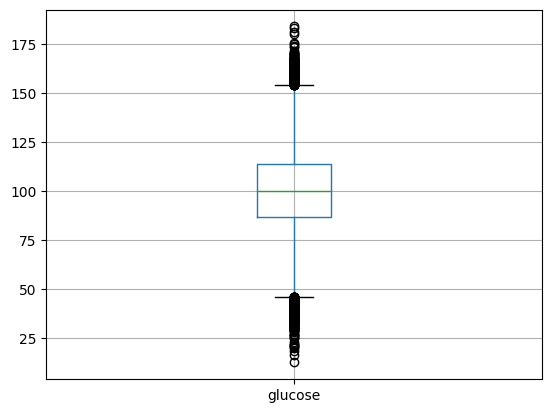

In [355]:
df.boxplot(column='glucose')

<Axes: xlabel='target', ylabel='count'>

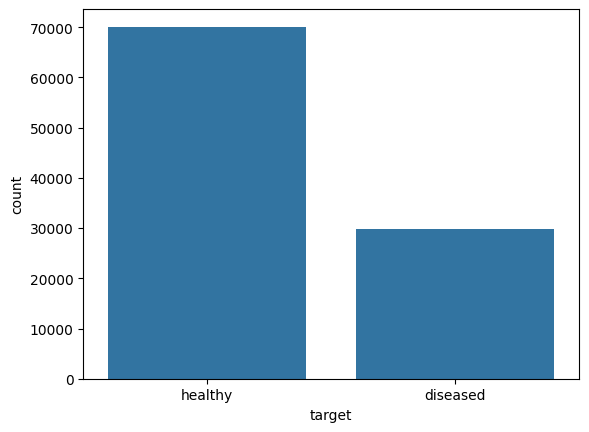

In [356]:
sns.countplot(x=df['target'])

In [357]:
# Menghapus kolom yang tidak diperlukan 
df = df.drop(columns=[

    # ID
    'survey_code',

    # redundant BMI
    'bmi_estimated',
    'bmi_scaled',
    'bmi_corrected',

    # kurang berguna
    'mental_health_score',
    'mental_health_support',

    # noisy
    'job_type',
    'occupation',
    'pet_owner',
    'daily_supplement_dosage',

    # konstan
    'electrolyte_level',
    'gene_marker_flag',
    'environmental_risk_score'
])

Feature engineering

In [358]:
df['health_risk_score'] = (
    df['stress_level'] +
    df['sugar_intake']/10 +
    df['screen_time'] -
    df['physical_activity']
)

df['metabolic_risk'] = (
    df['glucose'] +
    df['cholesterol'] +
    df['bmi']
)

df['sleep_risk'] = (
    df['work_hours'] -
    df['sleep_hours']
)

df['activity_balance'] = (
    df['daily_steps'] -
    (df['screen_time'] * 1000)
)

In [359]:
# Encode target
df['target'] = df['target'].map({
    'healthy': 0,
    'diseased': 1
})

In [360]:
X = df.drop('target', axis=1)
y = df['target']

In [361]:
print(df.select_dtypes(include='object').columns)

Index(['gender', 'sleep_quality', 'alcohol_consumption', 'smoking_level', 'education_level', 'diet_type', 'exercise_type', 'device_usage', 'healthcare_access', 'insurance', 'sunlight_exposure', 'caffeine_intake', 'family_history'], dtype='object')


Encoding Kategorikal

In [362]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

# Cari semua kolom object
cat_cols = df.select_dtypes(include='object').columns

# Encode semua kolom object
for col in cat_cols:
    df[col] = label_encoder.fit_transform(df[col].astype(str))

In [363]:
cat_features = X.select_dtypes(include='object').columns.tolist()

In [364]:
df.head()   

,age,gender,height,weight,bmi,waist_size,blood_pressure,heart_rate,cholesterol,glucose,insulin,sleep_hours,sleep_quality,work_hours,physical_activity,daily_steps,calorie_intake,sugar_intake,alcohol_consumption,smoking_level,water_intake,screen_time,stress_level,education_level,income,diet_type,exercise_type,device_usage,healthcare_access,insurance,sunlight_exposure,meals_per_day,caffeine_intake,family_history,target,health_risk_score,metabolic_risk,sleep_risk,activity_balance
0,56,1,173.416872,56.886640,18.915925,72.165130,118.264254,60.749825,214.580523,103.008176,14.983414,6.475885,1,7.671313,0.356918,13320.942595,2673.546960,44.476887,2,2,1.694262,5.003963,2,3,6759.821719,2,2,0,2,0,0,5,1,0,0,11.094734,336.504624,1.195429,8316.979195
1,69,0,163.207380,97.799859,36.716278,85.598889,117.917986,66.463696,115.794002,116.905134,10.131597,8.428410,2,9.515198,0.568219,11911.201401,2650.376972,74.663405,1,1,0.716409,5.925455,3,1,6240.517690,2,0,2,1,0,0,5,0,1,0,15.823576,269.415413,1.086788,5985.746507
2,46,1,177.281966,80.687562,25.673050,90.295030,123.073698,76.043212,138.134787,89.180302,14.983414,5.702164,3,5.829853,3.764406,2974.035375,1746.755144,19.702382,1,0,2.487900,4.371250,0,2,3429.179266,2,0,0,0,1,0,4,1,0,0,2.577082,252.988140,0.127689,-1397.215103
3,32,0,172.101255,63.142868,21.318480,100.504211,148.173453,68.781981,203.017447,128.375798,18.733179,5.188316,2,9.489693,0.889474,5321.539497,2034.193242,82.580050,0,0,2.643335,4.116064,10,2,2618.503534,3,1,1,1,0,0,1,2,0,0,21.484595,352.711725,4.301377,1205.475319
4,60,0,163.608816,40.000000,14.943302,69.021150,150.613181,92.335358,200.412439,94.813332,16.038701,7.912514,2,7.275450,2.901608,9791.376712,2386.210257,45.961322,2,0,1.968393,3.180087,9,2,3662.086276,2,3,1,1,1,0,1,0,1,0,13.874611,310.169073,-0.637064,6611.289544


In [365]:
# ============================================================
# SPLIT DATA
# ============================================================

from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Mengatasi Imbalanced Data

In [366]:
# ============================================================
# INSTALL SMOTE
# ============================================================

!pip install imbalanced-learn

# ============================================================
# IMPORT LIBRARY
# ============================================================

from imblearn.over_sampling import SMOTE

# ============================================================
# CEK DISTRIBUSI DATA SEBELUM SMOTE
# ============================================================

print("Distribusi target sebelum SMOTE:\n")

print(y_train.value_counts())

# ============================================================
# SMOTE
# ============================================================

smote = SMOTE(
    sampling_strategy='auto',
    random_state=42,
    k_neighbors=5
)

x_train_smote, y_train_smote = smote.fit_resample(
    x_train,
    y_train
)

# ============================================================
# CEK DISTRIBUSI DATA SETELAH SMOTE
# ============================================================

print("\nDistribusi target setelah SMOTE:\n")

print(y_train_smote.value_counts())

Distribusi target sebelum SMOTE:

target
0    56120
1    23880
Name: count, dtype: int64

Distribusi target setelah SMOTE:

target
0    56120
1    56120
Name: count, dtype: int64


Train Data

In [367]:
# ============================================================
# MODEL CATBOOST
# ============================================================

cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.02,
    depth=10,
    loss_function='Logloss',
    eval_metric='F1',
    l2_leaf_reg=5,
    random_strength=2,
    bagging_temperature=1,
    random_state=42,
    verbose=200
)

# ============================================================
# TRAINING MODEL
# ============================================================

print("====================================")
print("TRAINING MODEL DIMULAI")
print("====================================")

cat_model.fit(
    x_train_smote,
    y_train_smote,
    cat_features=cat_features,
    eval_set=(x_test, y_test)
)

print("====================================")
print("TRAINING MODEL SELESAI")
print("====================================")

TRAINING MODEL DIMULAI
0:	learn: 0.6461940	test: 0.2715890	best: 0.2715890 (0)	total: 707ms	remaining: 11m 46s
200:	learn: 0.6871087	test: 0.2372467	best: 0.2715890 (0)	total: 2m 28s	remaining: 9m 49s
400:	learn: 0.7001645	test: 0.2303708	best: 0.2715890 (0)	total: 4m 36s	remaining: 6m 52s
600:	learn: 0.7118399	test: 0.2262927	best: 0.2715890 (0)	total: 6m 43s	remaining: 4m 28s
800:	learn: 0.7305938	test: 0.2176508	best: 0.2715890 (0)	total: 9m 12s	remaining: 2m 17s
999:	learn: 0.7529389	test: 0.2153648	best: 0.2715890 (0)	total: 11m 41s	remaining: 0us

bestTest = 0.271589026
bestIteration = 0

Shrink model to first 1 iterations.
TRAINING MODEL SELESAI


Tes Data

In [368]:
y_prob = cat_model.predict_proba(x_test)[:,1]
threshold = 0.50
y_pred = (y_prob > threshold).astype(int)


# Evaluasi
cat_acc = accuracy_score(y_test, y_pred)

print(classification_report(y_test, y_pred))

print('Akurasi CatBoost = {:.2f}%'.format(cat_acc*100))


              precision    recall  f1-score   support

           0       0.70      0.76      0.73     13977
           1       0.30      0.24      0.27      6023

    accuracy                           0.60     20000
   macro avg       0.50      0.50      0.50     20000
weighted avg       0.58      0.60      0.59     20000

Akurasi CatBoost = 60.44%
